#6. Evaluation and Comparison

# Classification:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
df = pd.read_csv("Preprocessed_dataset.csv")
df.head()

,date,price,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,has_lavatory,single_floor,quartile_zone
0,2014-09-26,-0.819164,1,False,-1.540812,False,False,True,False,True,2
1,2014-05-14,0.108578,2,True,0.431209,False,False,False,True,True,2
2,2015-03-23,0.550818,4,False,1.192817,False,False,False,True,False,2
3,2014-07-15,1.440104,3,False,-0.316799,False,False,False,True,False,3
4,2015-04-14,-0.602851,1,False,-1.296009,False,False,False,True,True,3


separate the dataset into features (X) and target (y). This prepares the data for the classification model.


In [ ]:
TARGET_COL = "quartile_zone"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", sorted(y.unique()))

X shape: (6576, 11)
y shape: (6576,)
Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


 define the three different train-test split sizes (70/30, 80/20, 90/10) and the impurity criteria (Gini and Entropy) that will be used to train six Decision Tree models.


In [ ]:
splits = [
    (0.30, "70/30"),
    (0.20, "80/20"),
    (0.10, "90/10"),
]

criteria = ["gini", "entropy"]

results = []

In [ ]:
for col in X.columns:
    if X[col].dtype == 'object':
        print("Dropping non-numeric column:", col)
        X = X.drop(columns=[col])

Dropping non-numeric column: date


 train a Decision Tree model for each split size and each criterion. It also calculates the accuracy and confusion matrix for every experiment.


In [ ]:
for test_size, split_name in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    for crit in criteria:
        clf = DecisionTreeClassifier(criterion=crit, random_state=42)
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            "Split": split_name,
            "Criterion": crit,
            "Accuracy": acc,
            "ConfusionMatrix": cm,
            "Model": clf
        })

        print("=" * 55)
        print(f"Split: {split_name} | Criterion: {crit}")
        print("Accuracy:", round(acc, 4))
        print("Confusion Matrix:\n", cm)


Split: 70/30 | Criterion: gini
Accuracy: 0.5297
Confusion Matrix:
 [[338 126  21   5]
 [147 264 116  53]
 [ 27 109 237 137]
 [  9  48 130 206]]
Split: 70/30 | Criterion: entropy
Accuracy: 0.5124
Confusion Matrix:
 [[326 137  21   6]
 [149 265 117  49]
 [ 22 123 234 131]
 [ 12  67 128 186]]
Split: 80/20 | Criterion: gini
Accuracy: 0.5243
Confusion Matrix:
 [[227  85  10   5]
 [ 96 182  73  36]
 [ 17  86 155  82]
 [  8  27 101 126]]
Split: 80/20 | Criterion: entropy
Accuracy: 0.5243
Confusion Matrix:
 [[227  81  15   4]
 [ 86 176  90  35]
 [ 13  78 166  83]
 [  4  36 101 121]]
Split: 90/10 | Criterion: gini
Accuracy: 0.541
Confusion Matrix:
 [[112  44   7   1]
 [ 49  87  44  13]
 [  6  41  90  33]
 [  2  17  45  67]]
Split: 90/10 | Criterion: entropy
Accuracy: 0.541
Confusion Matrix:
 [[114  47   3   0]
 [ 47  90  39  17]
 [  8  35  90  37]
 [  4  18  47  62]]


 gathering all experiment results into a single comparison table that shows the accuracy for each split and criterion.


In [ ]:
comparison_df = pd.DataFrame([
    {"Split": r["Split"], "Criterion": r["Criterion"], "Accuracy": r["Accuracy"]}
    for r in results
])
comparison_df["Accuracy"] = comparison_df["Accuracy"].round(4)

print("\n=== Decision Tree Accuracy Comparison ===")
comparison_df


=== Decision Tree Accuracy Comparison ===


,Split,Criterion,Accuracy
0,70/30,gini,0.5297
1,70/30,entropy,0.5124
2,80/20,gini,0.5243
3,80/20,entropy,0.5243
4,90/10,gini,0.5410
5,90/10,entropy,0.5410


A bar chart is generated in this block to visually compare the accuracy values across all six Decision Tree configurations.


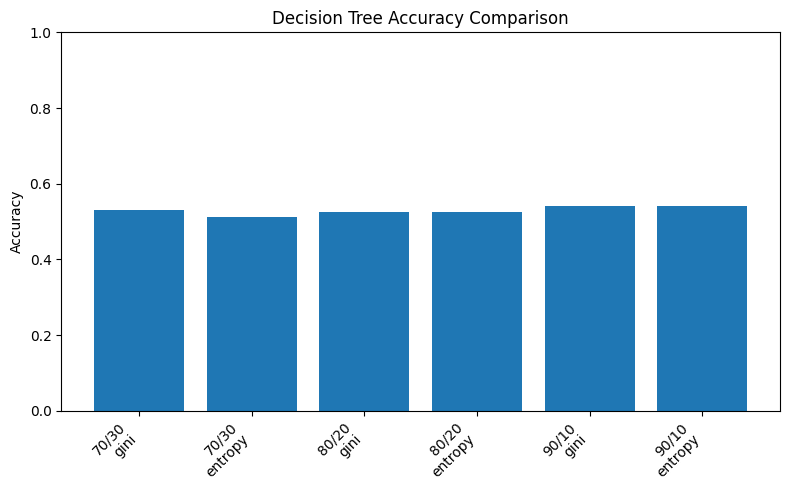

In [ ]:
labels = [f"{r['Split']}\n{r['Criterion']}" for r in results]
accuracies = [r["Accuracy"] for r in results]

plt.figure(figsize=(8, 5))
plt.bar(labels, accuracies)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Decision Tree Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

 identifies the best-performing model using Entropy and the best-performing model using Gini to use them in the visualization step.


In [ ]:
entropy_models = [r for r in results if r["Criterion"] == "entropy"]
gini_models    = [r for r in results if r["Criterion"] == "gini"]

best_entropy = max(entropy_models, key=lambda r: r["Accuracy"])
best_gini    = max(gini_models,    key=lambda r: r["Accuracy"])

print("Best Entropy:", best_entropy["Split"], best_entropy["Accuracy"])
print("Best Gini:", best_gini["Split"], best_gini["Accuracy"])

Best Entropy: 90/10 0.541033434650456
Best Gini: 90/10 0.541033434650456


 visualizes the Decision Tree of the best Entropy model. A simplified tree is shown for better interpretability.


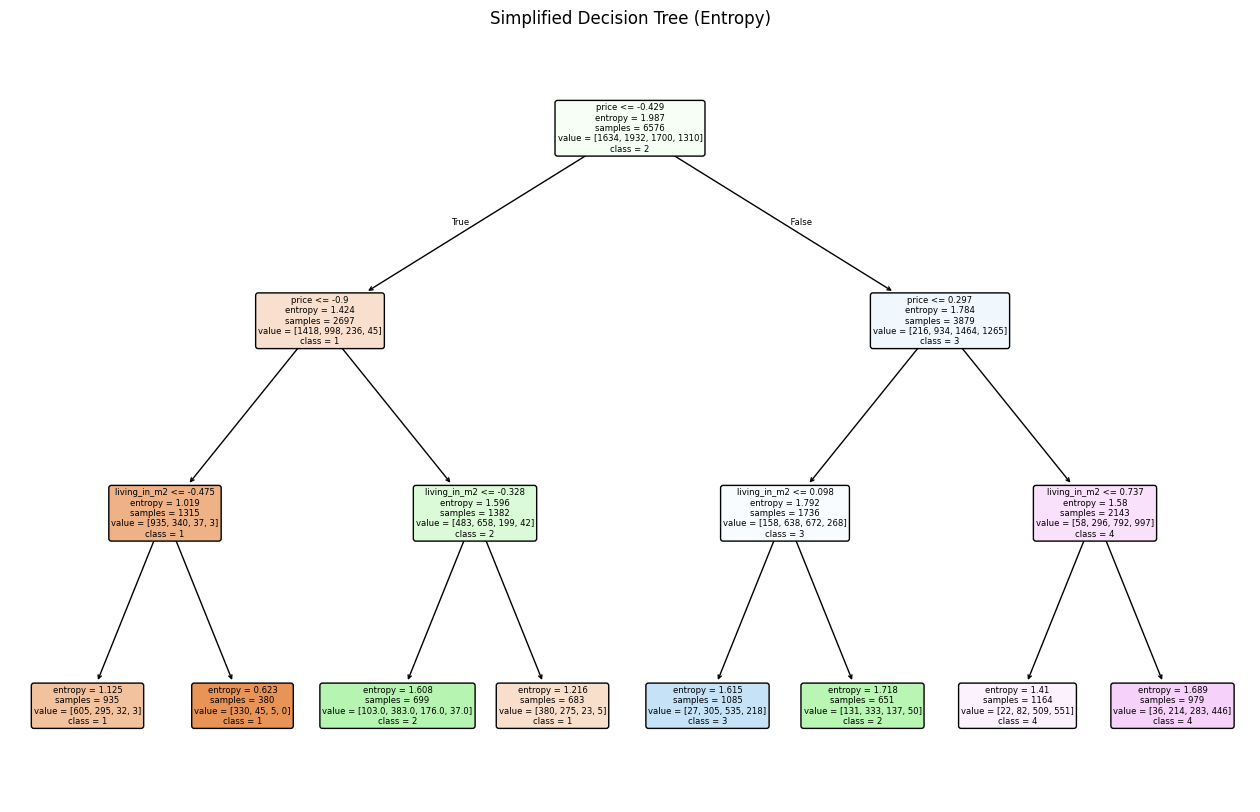

In [ ]:
simple_clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

simple_clf.fit(X, y)

plt.figure(figsize=(16, 10))
plot_tree(
    simple_clf,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True
)
plt.title("Simplified Decision Tree (Entropy)")
plt.show()

 visualizes the Decision Tree of the best Gini model. The simplified structure makes it easier to understand the model’s decision rules.


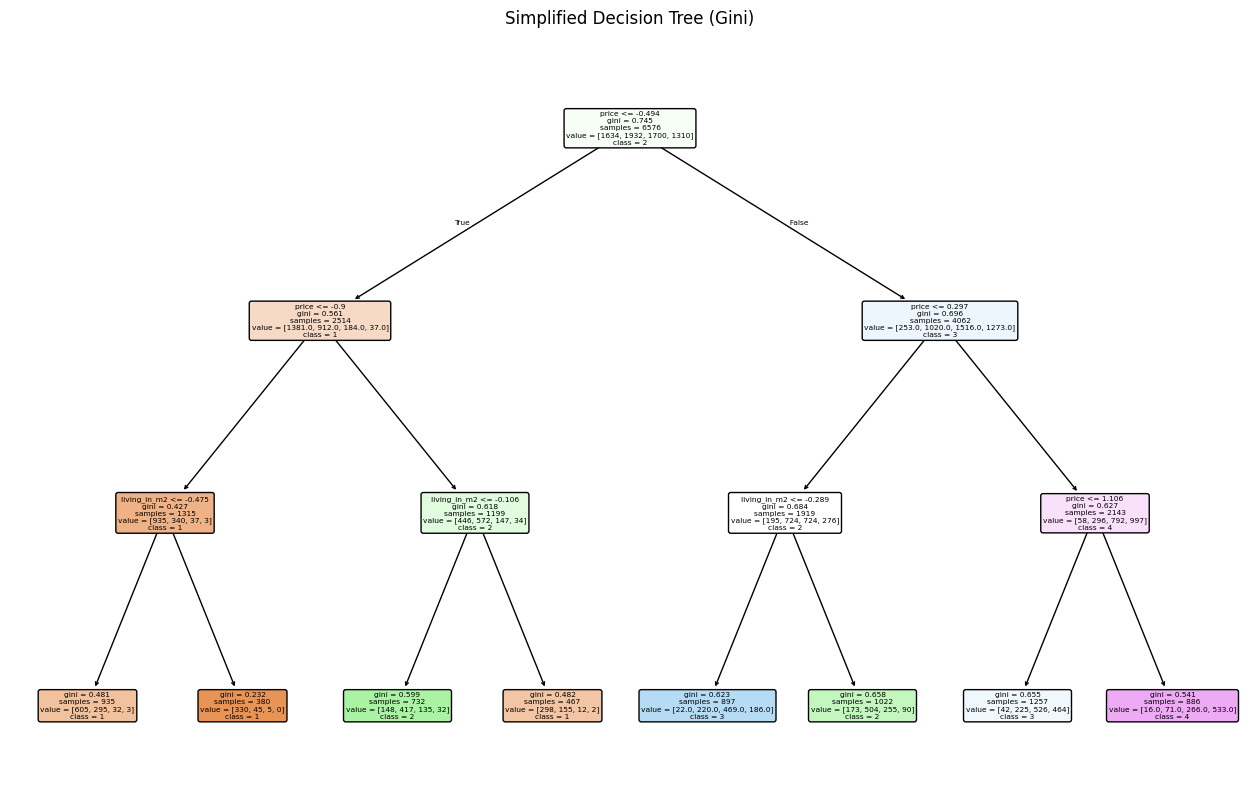

In [ ]:
simple_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)


simple_clf.fit(X, y)

plt.figure(figsize=(16, 10))
plot_tree(
    simple_clf,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True
)
plt.title("Simplified Decision Tree (Gini)")
plt.show()

# Clustering:

In [ ]:
# Select numerical features for clustering
features = ["price", "grade", "living_in_m2"]
X = df[features]

# Scale data (important for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- ## Silhouette Score for K = 2, 3, 4

In [ ]:
silhouette_scores = {}

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores


{2: np.float64(0.42889156203426193),
 3: np.float64(0.3220304783862873),
 4: np.float64(0.31628647442881674)}

- ## Elbow Method

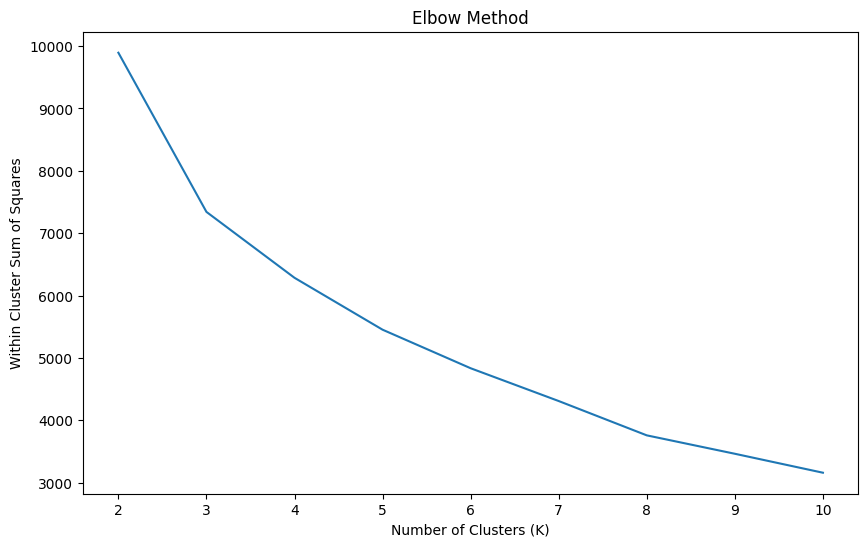

In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Sum of Squares")
plt.title("Elbow Method")
plt.show()


- ## Total Within Cluster Sum of Squares

In [ ]:
wcss = {}

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss[k] = kmeans.inertia_

wcss


{2: 9892.738023401382, 3: 7341.567639384741, 4: 6285.2183425861995}

- ## Visualization of clusters

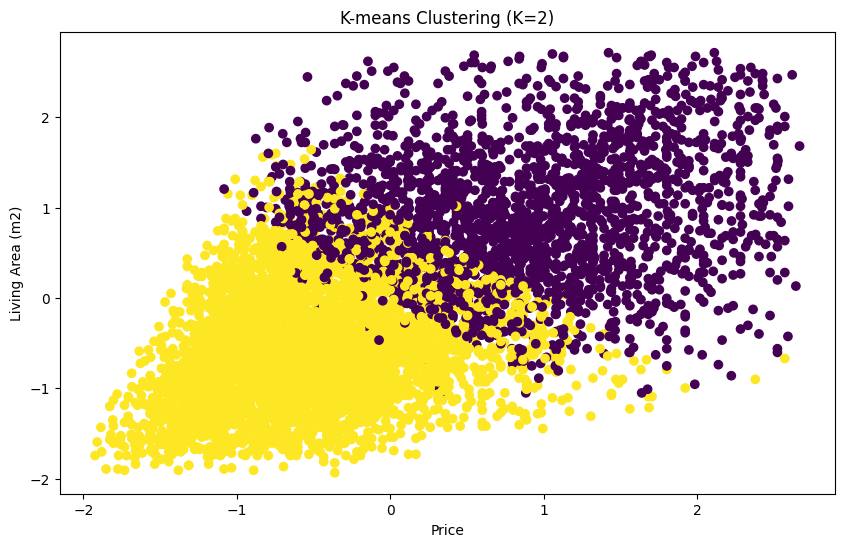

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

plt.scatter(df["price"], df["living_in_m2"], c=df["cluster"])
plt.xlabel("Price")
plt.ylabel("Living Area (m2)")
plt.title("K-means Clustering (K=2)")
plt.show()


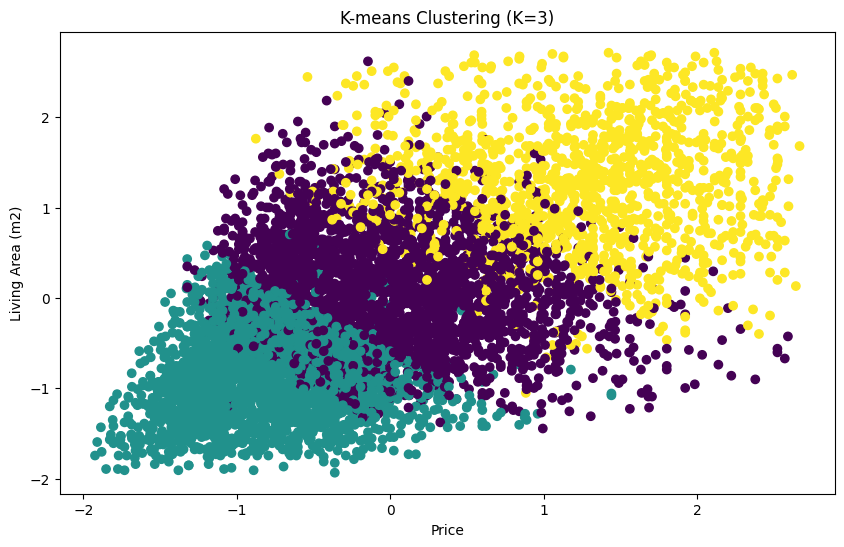

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

plt.scatter(df["price"], df["living_in_m2"], c=df["cluster"])
plt.xlabel("Price")
plt.ylabel("Living Area (m2)")
plt.title("K-means Clustering (K=3)")
plt.show()


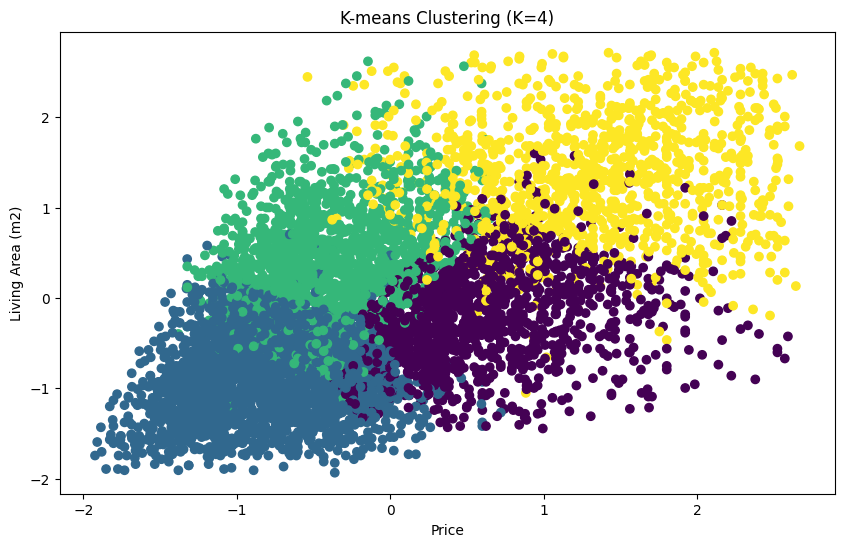

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

plt.scatter(df["price"], df["living_in_m2"], c=df["cluster"])
plt.xlabel("Price")
plt.ylabel("Living Area (m2)")
plt.title("K-means Clustering (K=4)")
plt.show()


In [ ]:
comparison_table = pd.DataFrame({
    "K": [2, 3, 4],
    "Silhouette": [float(silhouette_scores[k]) for k in [2,3,4]],
    "WCSS": [float(wcss[k]) for k in [2,3,4]]
}).round(4)

comparison_table.style.hide(axis="index")


K,Silhouette,WCSS
2,0.428900,9892.738000
3,0.322000,7341.567600
4,0.316300,6285.218300


 # 7. Findings and Discussion

- ## Decision Tree for classification visual representations

In [ ]:
clf.feature_names_in_


array(['price', 'grade', 'has_basement', 'living_in_m2', 'renovated',
       'nice_view', 'perfect_condition', 'has_lavatory', 'single_floor',
       'cluster'], dtype=object)

In [ ]:
feature_names = clf.feature_names_in_


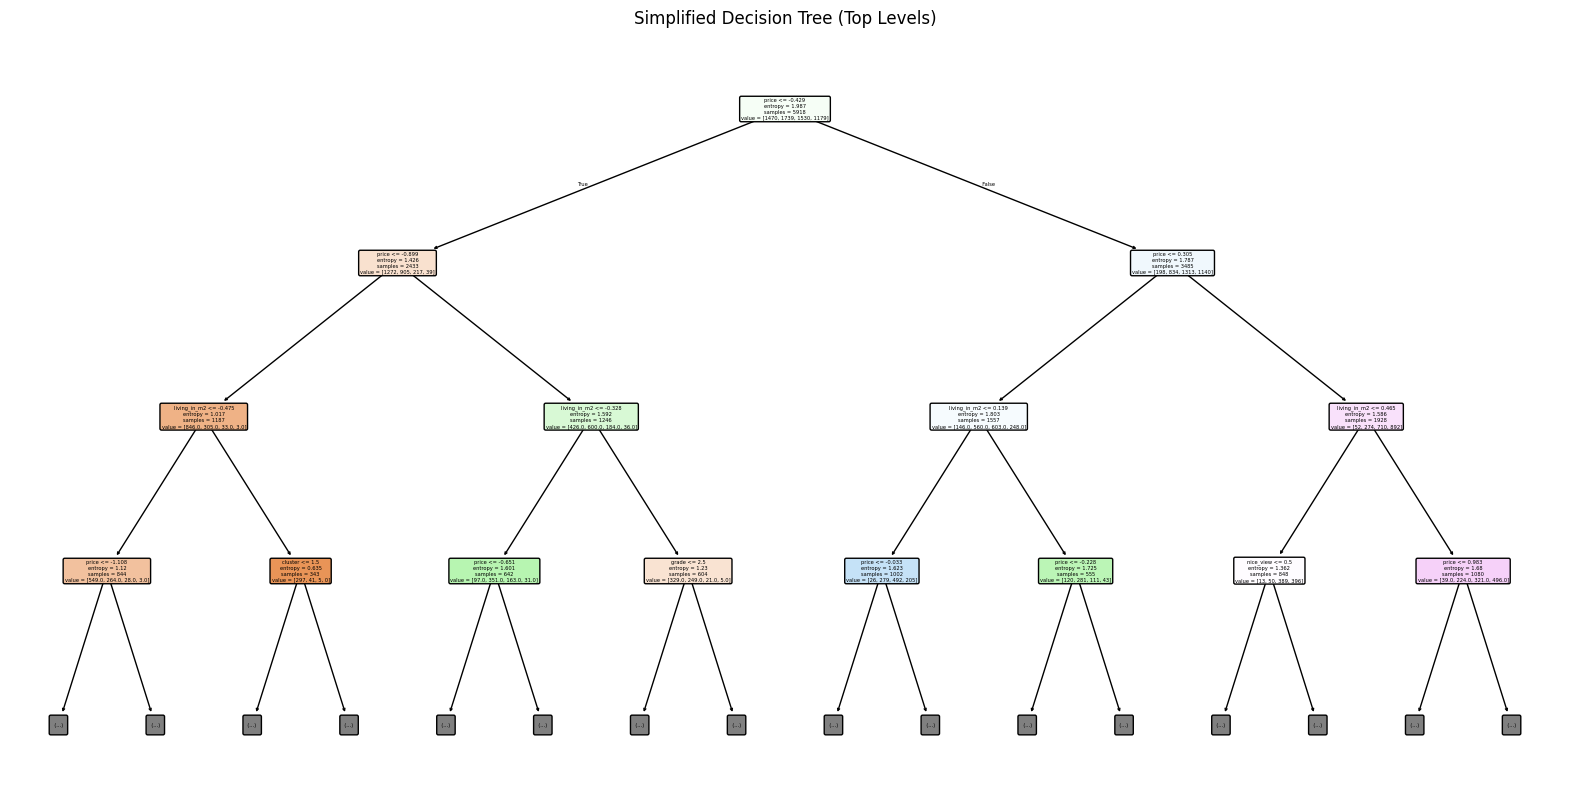

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=clf.feature_names_in_,
    filled=True,
    rounded=True,
    max_depth=3     #LIMIT THE DEPTH HERE
)
plt.title("Simplified Decision Tree (Top Levels)")
plt.show()


- ## plotting for clustering visual representations

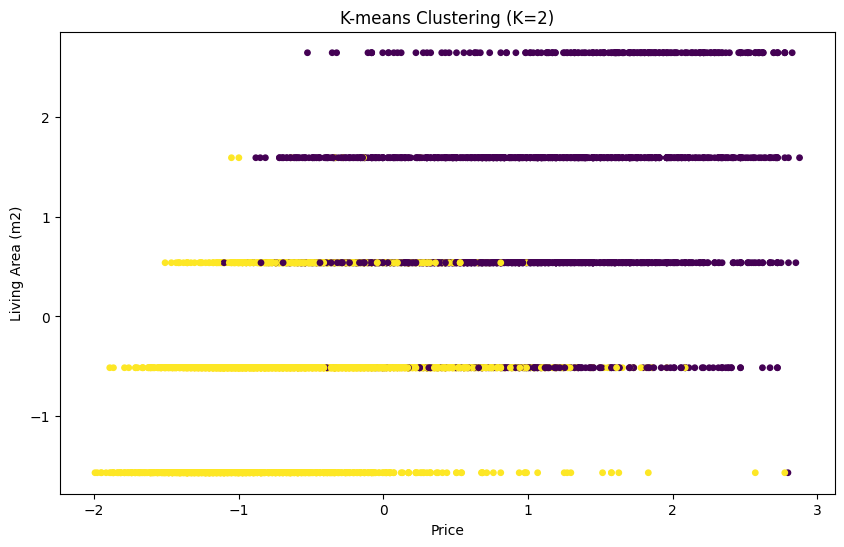

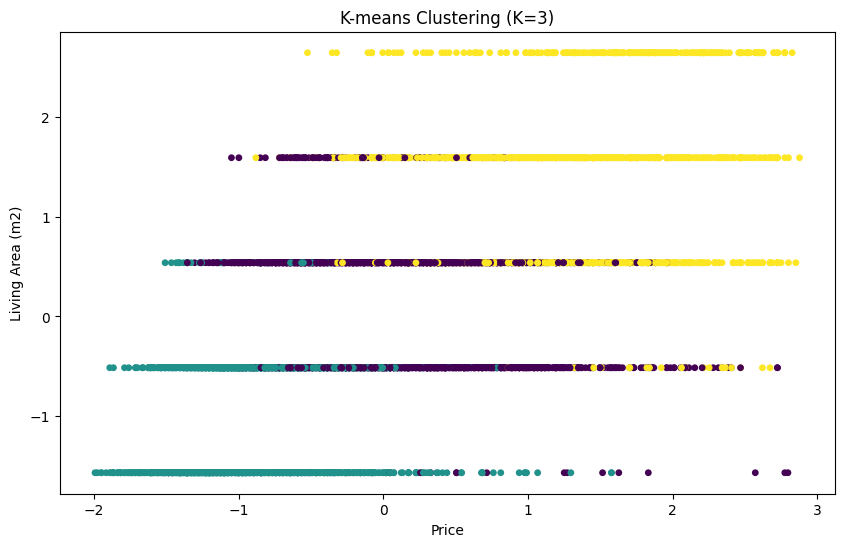

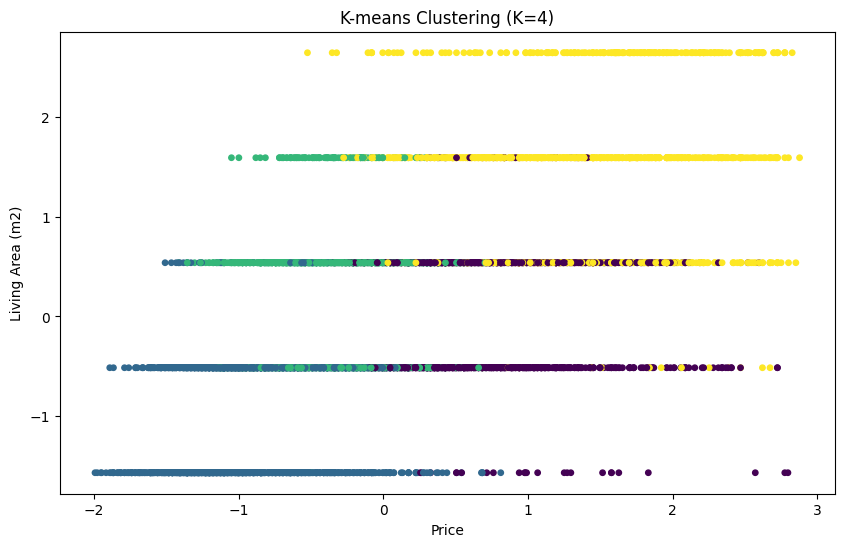

In [ ]:
# Plot clusters for K = 2, 3, 4
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(10, 6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=15)
    plt.title(f"K-means Clustering (K={k})")
    plt.xlabel("Price")
    plt.ylabel("Living Area (m2)")
    plt.show()
